# Set Configuration

In [14]:
from diffusion_hash_inv.config import MainConfig, HashConfig, MessageConfig, OutputConfig, Byte2RGBConfig
from diffusion_hash_inv.main import MainEP
from diffusion_hash_inv.utils import FileIO
from diffusion_hash_inv.main import RuntimeConfig

length = 16
iteration = 2**length

main_cfg = MainConfig(
    verbose_flag=False,
    clean_flag=True,
    debug_flag=False,
    make_image_flag=False,
)
hash_cfg = HashConfig(
    hash_alg="md5",
    length=length,
)
message_cfg = MessageConfig(
    message_flag=False,
    length=length,
    random_flag=False,
    seed_flag=True,
)
output_cfg = OutputConfig()
byte2rgb_cfg = Byte2RGBConfig()
rutime_cfg = RuntimeConfig(
    main=main_cfg,
    message=message_cfg,
    hash=hash_cfg,
    output=output_cfg,
    rgb=byte2rgb_cfg,
)

io_controller = FileIO(main_config=main_cfg, output_cfg=output_cfg)

Clearing generated files...



In [ ]:
main = MainEP(runtime_config=rutime_cfg, file_controller=io_controller)
main.run(iteration=iteration, mode="sequential")

In [16]:

from diffusion_hash_inv.logger.logger import Logs

log_hierarchy = list()
logs = Logs.get_logs(io_controller, hash_cfg, main_cfg, log_hierarchy)
print(len(logs))

65536


In [17]:
def get_step4(logs):
    step4_logs = []
    for log in logs:
        _tmp = list(log.values())
        assert len(_tmp) == 1, "Each log dictionary should contain exactly one key-value pair."
        log_dict = list(log.values())[0]
        if "Logs" in log_dict and "4th Step" in log_dict["Logs"]:
            step4_logs.append(log_dict["Logs"]["4th Step"])
    return step4_logs

In [18]:
from typing import List, Dict, Any

step4_logs: List[Dict[str, Any]] = get_step4(logs)
print(step4_logs[0])
beta_schedule = list()

{'1st Round': {'Loop Start': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '1st Loop': {'A': '0x76543210', 'B': '0x74e71fe5', 'C': '0x89abcdef', 'D': '0xfedcba98'}, '2nd Loop': {'A': '0xfedcba98', 'B': '0xde569561', 'C': '0x74e71fe5', 'D': '0x89abcdef'}, '3rd Loop': {'A': '0x89abcdef', 'B': '0x50aff2db', 'C': '0xde569561', 'D': '0x74e71fe5'}, '4th Loop': {'A': '0x74e71fe5', 'B': '0x8079b816', 'C': '0x50aff2db', 'D': '0xde569561'}, '5th Loop': {'A': '0xde569561', 'B': '0x27ba4b3f', 'C': '0x8079b816', 'D': '0x50aff2db'}, '6th Loop': {'A': '0x50aff2db', 'B': '0x2442f194', 'C': '0x27ba4b3f', 'D': '0x8079b816'}, '7th Loop': {'A': '0x8079b816', 'B': '0xfc7600f7', 'C': '0x2442f194', 'D': '0x27ba4b3f'}, '8th Loop': {'A': '0x27ba4b3f', 'B': '0xb2892c21', 'C': '0xfc7600f7', 'D': '0x2442f194'}, '9th Loop': {'A': '0x2442f194', 'B': '0x6163f76f', 'C': '0xb2892c21', 'D': '0xfc7600f7'}, '10th Loop': {'A': '0xfc7600f7', 'B': '0x7660f014', 'C': '0x6163f76f', 'D': '0xb289

In [19]:
def cumulative_block(byte_list: List[bytes], block: bytes, indent: int = 0) -> List[bytes]:
    """
    Seperate Block into bytes and cumulatively add to byte_list. Return the updated byte_list.
    """
    _byte = 0
    for byte in block:
        _byte = byte if len(byte_list) == 0 else byte + byte_list[-1]
        _byte = _byte % (0xff + 1) # Ensure byte value stays within 0-255
        if main_cfg.verbose_flag:
            # print(f"{'\t' * indent}Byte: {byte}")
            # print(f"{'\t' * (indent+1)}Cumulative Byte: {_byte}")
            pass
        byte_list.append(_byte)
    return byte_list


def make_beta_schedule(step4_logs: Dict[str, Any]) -> List[float]:
    step4_log: Dict[str, Any] = list(step4_logs.values())
    beta_schedule = []
    for log in step4_log:
        for key, value in log.items():
            if main_cfg.verbose_flag:
                # print(f"Key: {key}")
                pass
            for k, v in value.items():
                _v = Logs.str_to_bytes(v)
                if main_cfg.verbose_flag:
                    # print(f"\tKey: {k}, Value: {v}")
                    # print(f"\t\tConverted Value: {_v}")
                    pass
                cumulative_block(beta_schedule, _v, indent=3)
                
    return beta_schedule

In [20]:
from tqdm import tqdm

step4_log_process = tqdm(step4_logs, desc="Processing Step 4 Logs")
for log in step4_log_process:
    beta_schedule.append(make_beta_schedule(log))

Processing Step 4 Logs: 100%|██████████| 65536/65536 [00:27<00:00, 2348.38it/s]


In [21]:
print(len(beta_schedule))
print(len(beta_schedule[0]))
print(beta_schedule[0])
print(beta_schedule[1])

65536
1056
[1, 36, 105, 208, 89, 4, 209, 192, 190, 154, 84, 236, 98, 182, 232, 248, 110, 194, 244, 4, 120, 95, 126, 99, 236, 151, 100, 83, 81, 45, 231, 127, 125, 89, 19, 171, 137, 223, 116, 213, 73, 48, 79, 52, 189, 104, 53, 36, 173, 88, 37, 20, 100, 19, 5, 224, 190, 20, 169, 10, 126, 101, 132, 105, 221, 196, 227, 200, 72, 193, 121, 143, 223, 142, 128, 91, 57, 143, 36, 133, 99, 185, 78, 175, 214, 144, 219, 26, 154, 19, 203, 225, 49, 224, 210, 173, 253, 172, 158, 121, 157, 223, 208, 100, 139, 69, 144, 207, 79, 200, 128, 150, 22, 143, 71, 93, 89, 207, 207, 198, 234, 44, 29, 177, 216, 146, 221, 28, 67, 253, 72, 135, 57, 194, 238, 15, 11, 129, 129, 120, 156, 222, 207, 99, 135, 201, 186, 78, 175, 18, 9, 120, 42, 179, 223, 0, 252, 114, 114, 105, 101, 219, 219, 210, 72, 168, 152, 172, 13, 112, 103, 214, 136, 17, 61, 94, 16, 153, 197, 230, 85, 239, 249, 135, 253, 93, 77, 97, 194, 37, 28, 139, 236, 79, 70, 181, 212, 142, 28, 95, 206, 104, 114, 0, 118, 214, 198, 218, 80, 176, 160, 180, 76, 127, 

In [41]:
if main_cfg.verbose_flag:
    width = len(str(iteration))
    for i, beta in enumerate(beta_schedule):
        print(f"Beta Schedule {i:0{width}}:")
        print(f"{'\t' * 1}Beta: ", end="")
        for j, b in enumerate(beta):
            print(f"{b:03},", end=" ")
        print("\n")

In [23]:
import numpy as np

beta_array = np.array(beta_schedule)
print(beta_array.shape)
min = np.min(beta_array, axis=0)
max = np.max(beta_array, axis=0)
mean = np.mean(beta_array, axis=0)
var = np.var(beta_array, axis=0)
std = np.std(beta_array, axis=0)

np.set_printoptions(threshold=np.inf, linewidth=np.inf)

print(f"Min: {min}, Length: {len(min)}")
print(f"Max: {max}, Length: {len(max)}")
print(f"Mean: {mean}, Length: {len(mean)}")
print(f"Variance: {var}, Length: {len(var)}")
print(f"Standard Deviation: {std}, Length: {len(std)}")

(65536, 1056)
Min: [  1  36 105 208  89   4 209 192 190 154  84 236  98 182 232 248 110 194 244   4 120   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

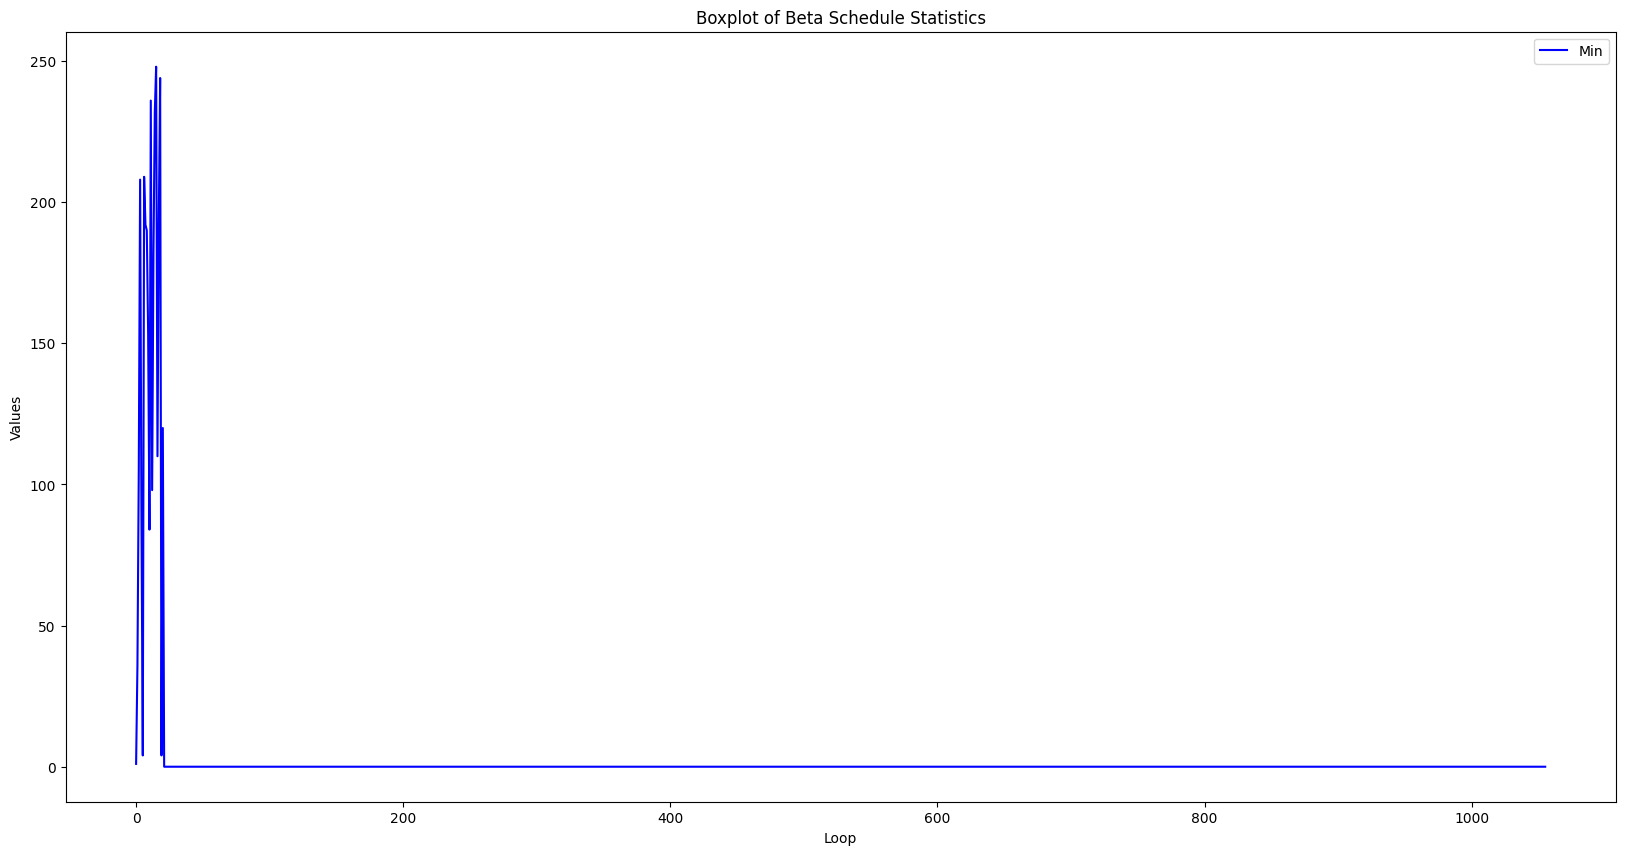

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(min, label='Min', color='blue')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

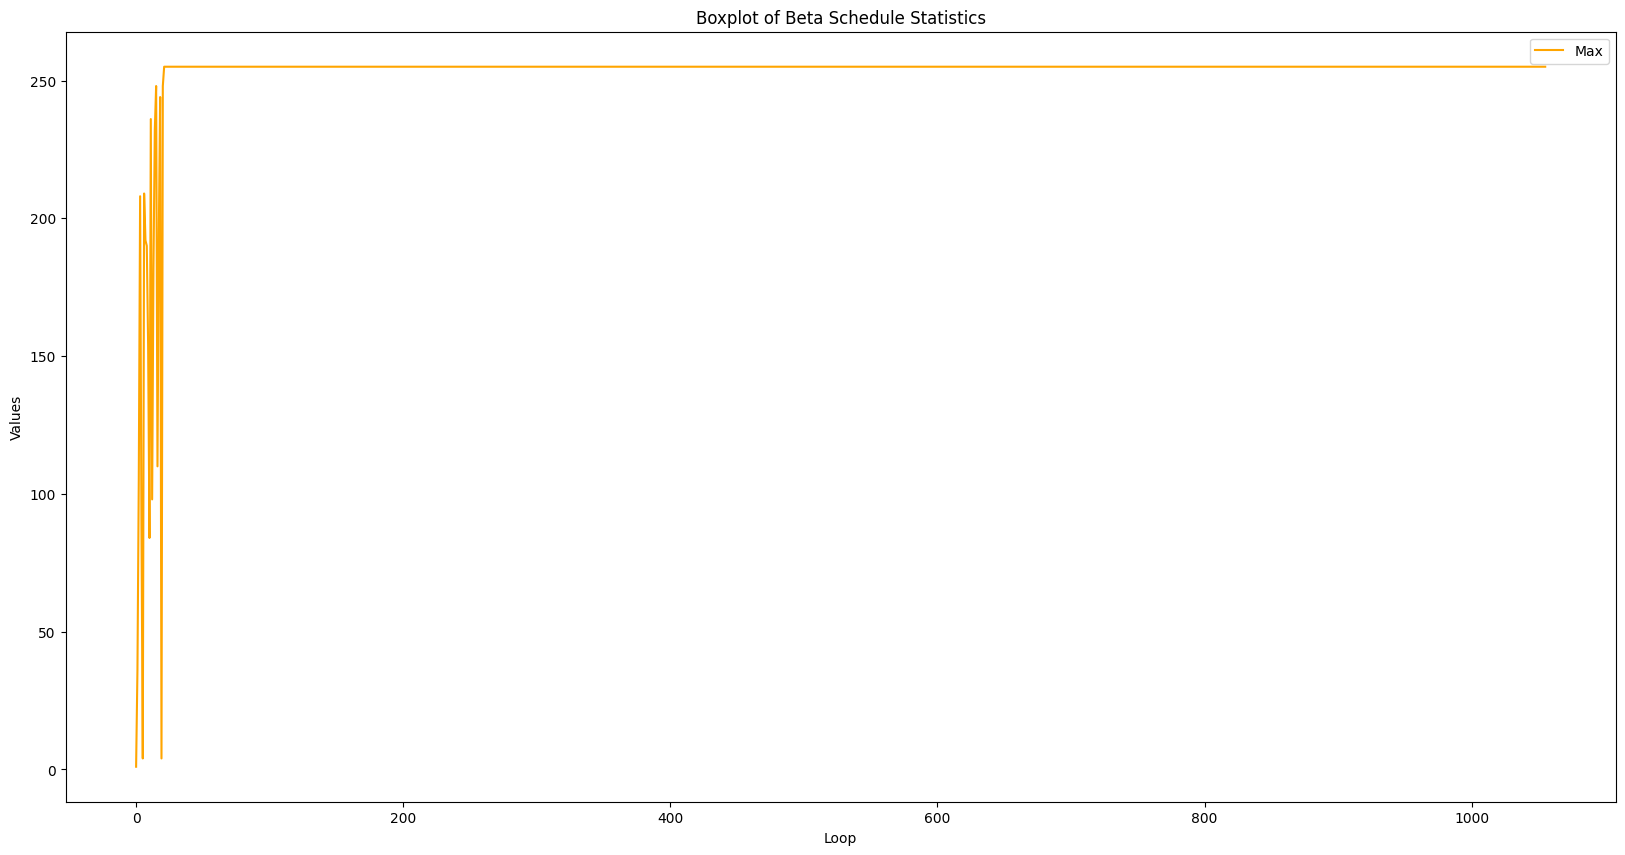

In [38]:
plt.figure(figsize=(20, 10))
plt.plot(max, label='Max', color='orange')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

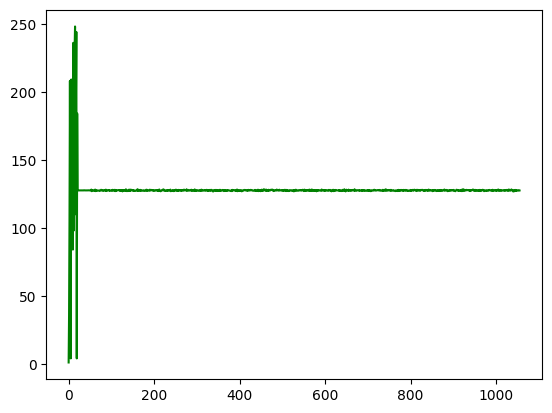

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(mean, label='Mean', color='green')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

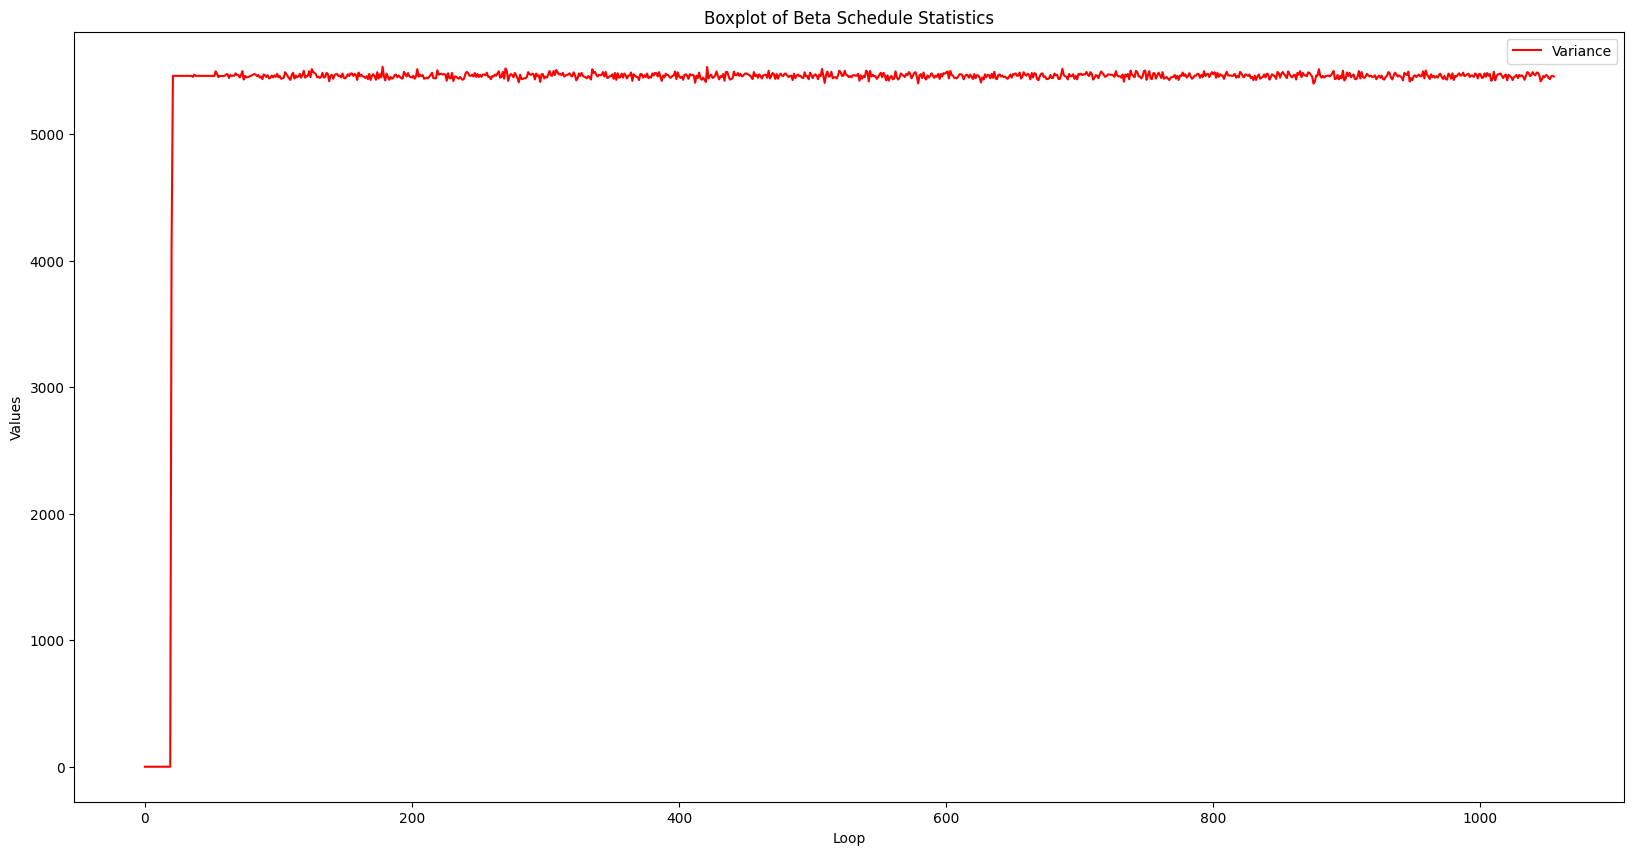

In [39]:
plt.figure(figsize=(20, 10))
plt.plot(var, label='Variance', color='red')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

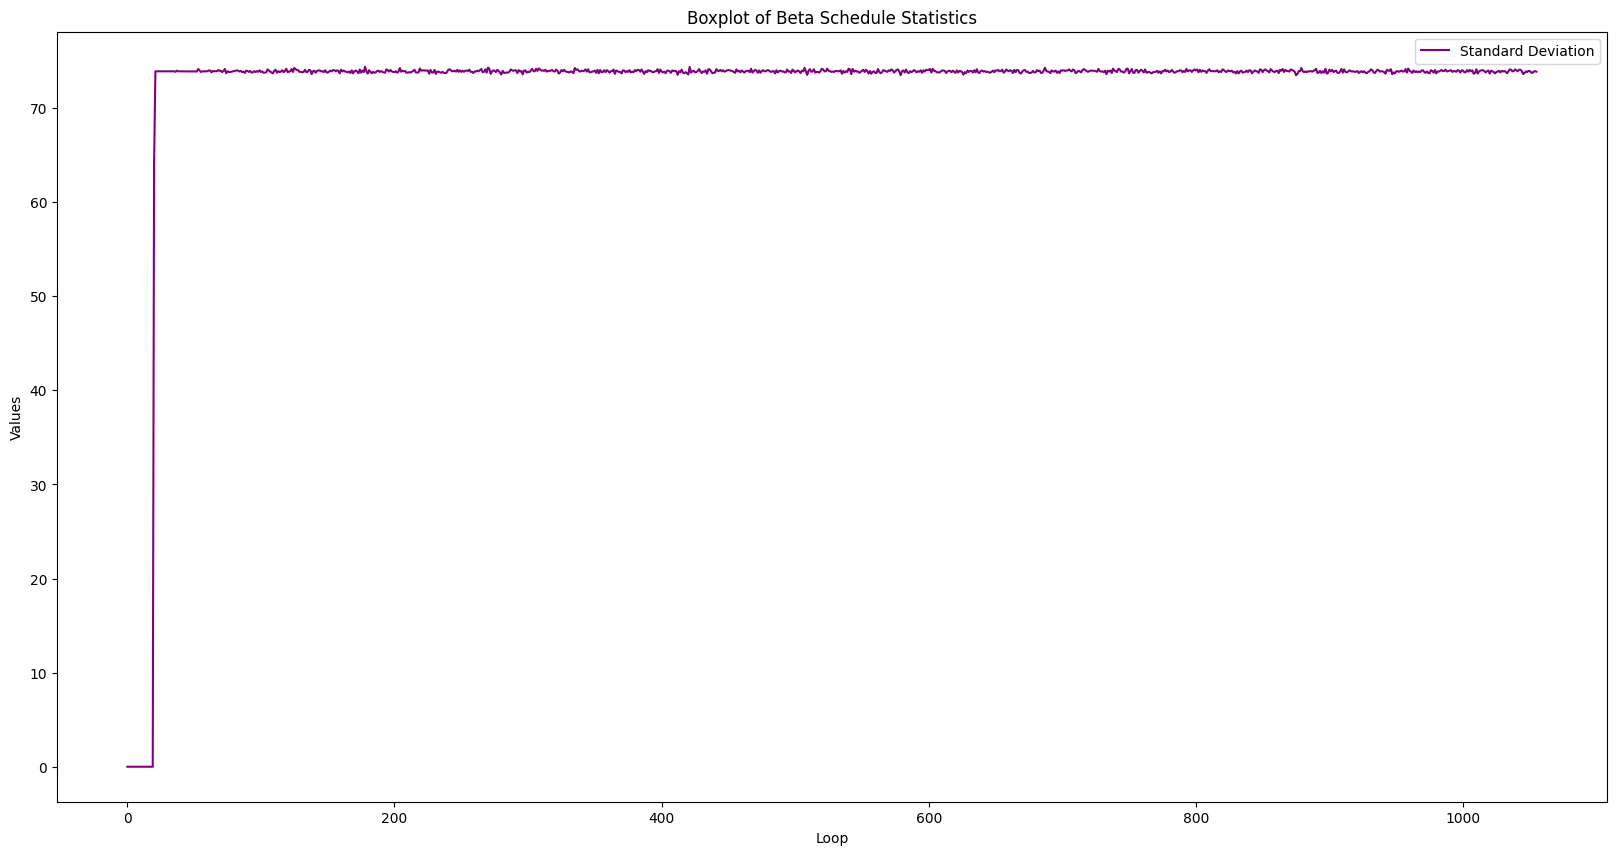

In [40]:
plt.figure(figsize=(20, 10))
plt.plot(std, label='Standard Deviation', color='purple')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()